# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7885s 46us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

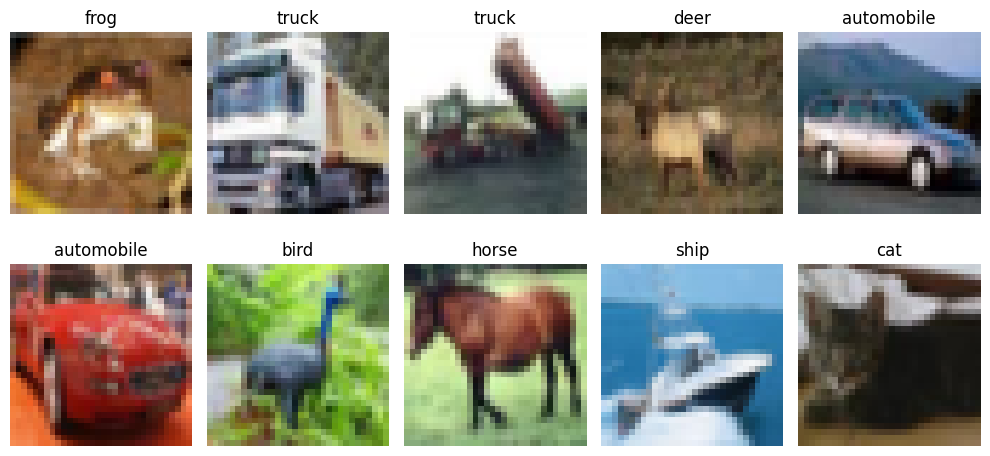

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.2630 - loss: 2.0012 - val_accuracy: 0.3238 - val_loss: 1.8295
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3115 - loss: 1.8759 - val_accuracy: 0.3360 - val_loss: 1.8122
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3363 - loss: 1.8161 - val_accuracy: 0.3738 - val_loss: 1.7362
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.3475 - loss: 1.7819 - val_accuracy: 0.3866 - val_loss: 1.7149
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3590 - loss: 1.7557 - val_accuracy: 0.3950 - val_loss: 1.7147
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3644 - loss: 1.7384 - val_accuracy: 0.4020 - val_loss: 1.6793
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3721 - loss: 1.7206 - val_accuracy: 0.4206 - val_loss: 1.6842
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3801 - loss: 1.7030 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4300 - loss: 1.6469
ANN Test Accuracy: 0.4300000071525574


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 86ms/step - accuracy: 0.4820 - loss: 1.4690 - val_accuracy: 0.4690 - val_loss: 1.5673
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.6137 - loss: 1.1040 - val_accuracy: 0.6054 - val_loss: 1.1208
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.6771 - loss: 0.9293 - val_accuracy: 0.6292 - val_loss: 1.0911
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.7140 - loss: 0.8234 - val_accuracy: 0.6688 - val_loss: 1.0099
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 93ms/step - accuracy: 0.7489 - loss: 0.7182 - val_accuracy: 0.6942 - val_loss: 0.8723
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 89ms/step - accuracy: 0.7749 - loss: 0.6459 - val_accuracy: 0.7280 - val_loss: 0.8148
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 86ms/step - accuracy: 0.7957 - loss: 0.5815 - val_accuracy: 0.7214 - val_loss: 0.8460
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.8153 - loss: 0.5283 - 

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7419 - loss: 0.8786
CNN Test Accuracy: 0.7419000267982483


## 📈 Compare Learning Curves

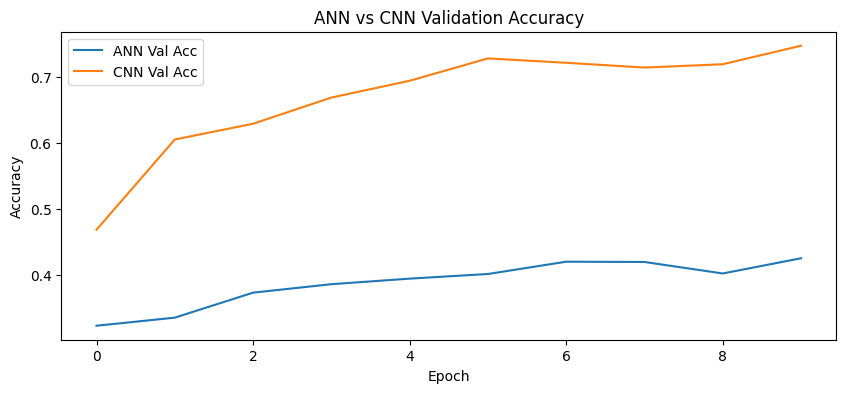

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4300
1,CNN,0.7419


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

**Task 1 — Increase ANN Layout**

In [ ]:
advanced_ann = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(1024,activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(512,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256,activation='relu'),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

advanced_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

advanced_ann.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 58ms/step - accuracy: 0.2289 - loss: 2.0570 - val_accuracy: 0.3112 - val_loss: 1.8888
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.2896 - loss: 1.9269 - val_accuracy: 0.3255 - val_loss: 1.8726
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.3085 - loss: 1.8828 - val_accuracy: 0.3326 - val_loss: 1.8495
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.3232 - loss: 1.8482 - val_accuracy: 0.3509 - val_loss: 1.8174
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.3311 - loss: 1.8255 - val_accuracy: 0.3605 - val_loss: 1.8049
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.3383 - loss: 1.8035 - val_accuracy: 0.3630 - val_loss: 1.7829
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.3478 - loss: 1.7869 - val_accuracy: 0.3739 - val_loss: 1.7618
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.3556 - loss: 1.7716 - 

**Task 2 — CNN Filters 32 → 64 → 128**

In [ ]:
advanced_cnn = models.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(32,3,activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10,activation='softmax')
])

**Task 3 & 4 — 20 Epochs + EarlyStopping**

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

advanced_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

advanced_history = advanced_cnn.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.2,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 86ms/step - accuracy: 0.4581 - loss: 1.5426 - val_accuracy: 0.5026 - val_loss: 1.5063
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.5898 - loss: 1.1671 - val_accuracy: 0.5413 - val_loss: 1.4082
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.6453 - loss: 1.0116 - val_accuracy: 0.6025 - val_loss: 1.1572
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.6884 - loss: 0.8914 - val_accuracy: 0.6162 - val_loss: 1.1431
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.7173 - loss: 0.8101 - val_accuracy: 0.6627 - val_loss: 0.9766
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.7420 - loss: 0.7398 - val_accuracy: 0.6947 - val_loss: 0.9095
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 87ms/step - accuracy: 0.7628 - loss: 0.6782 - val_accuracy: 0.6633 - val_loss: 1.0994
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.7812 - loss: 0.6227 - 

**Task 5 — Data Augmentation Network**

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name="data_augmentation")

augmented_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

augmented_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)
aug_history = augmented_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_test_norm, y_test),
    callbacks=[early_stop]
)
aug_test_loss, aug_test_acc = augmented_model.evaluate(
    x_test_norm,
    y_test,
    verbose=0
)

print(f"Augmented CNN Test Accuracy: {aug_test_acc:.4f}")
print("Epochs trained:", len(aug_history.history['loss']))

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 118s 146ms/step - accuracy: 0.3892 - loss: 1.7125 - val_accuracy: 0.4879 - val_loss: 1.4626
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 145s 150ms/step - accuracy: 0.4933 - loss: 1.4162 - val_accuracy: 0.5409 - val_loss: 1.2755
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 115s 147ms/step - accuracy: 0.5495 - loss: 1.2722 - val_accuracy: 0.5401 - val_loss: 1.3241
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 116s 148ms/step - accuracy: 0.5831 - loss: 1.1876 - val_accuracy: 0.6170 - val_loss: 1.0849
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 119s 152ms/step - accuracy: 0.6090 - loss: 1.1138 - val_accuracy: 0.6808 - val_loss: 0.9134
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 137s 146ms/step - accuracy: 0.6310 - loss: 1.0672 - val_accuracy: 0.6109 - val_loss: 1.1171
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 123s 157ms/step - accuracy: 0.6449 - loss: 1.0241 - val_accuracy: 0.6741 - val_loss: 0.9460
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 133s 145ms/step - accuracy: 0.6620 -

Final Comparison DataFrame

In [ ]:
ann_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)[1]
cnn_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)[1]
adv_acc = advanced_cnn.evaluate(x_test_norm, y_test, verbose=0)[1]
aug_acc = augmented_model.evaluate(x_test_norm, y_test, verbose=0)[1]

comparison = pd.DataFrame({
    "Model":[
        "ANN",
        "CNN",
        "Advanced CNN",
        "Augmented CNN"
    ],
    "Test Accuracy":[
        ann_acc,
        cnn_acc,
        adv_acc,
        aug_acc
    ]
})

comparison

,Model,Test Accuracy
0,ANN,0.4300
1,CNN,0.7419
2,Advanced CNN,0.7256
3,Augmented CNN,0.7361


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**